Question 1a

In [22]:
import numpy as np


In [23]:
#user defined function that calculates Q and R
def QR(A):

    #initialize variables
    n = A.shape[0]

    Q = np.zeros((n, n))
    R = np.zeros((n, n))

    for i in range(n):
        v = A[:, i]

        for j in range(i):
            R[j, i] = np.dot(Q[:, j], v)
            v = v - R[j, i] * Q[:, j]
        
        #perform normalization step
        R[i, i] = np.linalg.norm(v)
        Q[:, i] = v / R[i, i]

    #set a limit for tiny values to be set as zero (e.g. e-17)
    tol = 1e-12
    Q[np.abs(Q) < tol] = 0
    R[np.abs(R) < tol] = 0

    #return Q and R
    return Q, R


Question 1b

In [24]:
A = np.array([[6, 2, 1, 0],
     [2, 5, 2, 1],
     [1, 2, 4, 2],
     [0, 1, 2, 3]], dtype=float)

lim = 1e-12 # set limit for tiny values
Q, R = QR(A) #get Q and R

print("\n Q is:\n", Q)
print("\n R is: ", R)

#get A from Q and R
resulting_A = np.matmul(Q, R)
resulting_A[np.abs(resulting_A) < lim] = 0

print("\nA is: \n", resulting_A)

#get Q transpose
Qt = np.matrix.transpose(Q)
#show that Q * Qt gives identity matrix
identity = np.matmul(Q, Qt)
identity[np.abs(identity) < lim] = 0

print("\nQ^tQ matrix: \n", identity)


 Q is:
 [[ 9.37042571e-01 -3.38550227e-01 -7.48592962e-04  8.56411288e-02]
 [ 3.12347524e-01  8.57296543e-01 -4.07983164e-01 -3.21154233e-02]
 [ 1.56173762e-01  3.16708277e-01  8.20457886e-01 -4.49615926e-01]
 [ 0.00000000e+00  2.23879989e-01  4.00497234e-01  8.88526711e-01]]

 R is:  [[6.40312424 3.74817029 2.18643267 0.62469505]
 [0.         4.4666788  3.09063594 2.16235306]
 [0.         0.         3.26611109 2.43442431]
 [0.         0.         0.         1.73423286]]

A is: 
 [[6. 2. 1. 0.]
 [2. 5. 2. 1.]
 [1. 2. 4. 2.]
 [0. 1. 2. 3.]]

Q^tQ matrix: 
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


Question 1c

In [25]:
#User defined Iterative QR decomposition method
def iterQR(A, tol=1e-6):
    n = A.shape[0]
    max_iters = 100

    #initialize v to identity
    v = np.eye(n)

    for _ in range(max_iters):
        #get Q and R
        Q, R = QR(A)
        #get new A
        A = np.matmul(R, Q)
        #multiply V on the right by Q
        v = np.matmul(v, Q)

        #Check off diagonal elements of A
        off_diag = A - np.diag(np.diag(A))
        if np.linalg.norm(off_diag) < tol:
            #done if the magnitude is less than tol
            break
    
    #get the eignenvalues and eigenvectors
    eigvals = np.diag(A)
    eigvecs = v

    return eigvals, eigvecs

Question 1d

In [26]:
eigvals, eigvecs = iterQR(A)

print("\n The eigen values are: ", eigvals)
print("\n The eigen vectors are: \n", eigvecs)


 The eigen values are:  [8.90537507 5.06078265 2.7049735  1.32886878]

 The eigen vectors are: 
 [[ 0.5810779  -0.71777832  0.37178377  0.09444361]
 [ 0.60741532  0.10278356 -0.77958336  0.11283595]
 [ 0.47341814  0.46858312  0.33412929 -0.66683037]
 [ 0.26319264  0.50463818  0.37733835  0.73053796]]


Question 2a - skip

Question 2b

In [27]:
#Function to define the equation from the problem
def f(x):
    return 5*np.exp(-x) + x - 5

#Function to find an interval to search over
#max 20 as it is a large number for derivatives
def find_interval(step=0.1, max_x=20):
    a = 0
    b = a + step

    while b <= max_x:
        if f(a)*f(b) < 0:
            return a, b
        a = b
        b += step

    raise ValueError("No root found in range")

#Function to do binary search
def binary_search(a, b, acc=1e-6):
    while (b - a) / 2 > acc:
        #get the mid point
        mid = (a + b) / 2

        if f(mid) == 0:
            #mid is the minima
            return mid
        
        #otherwise, shift the range
        elif f(a) * f(mid) < 0:
            b = mid
        else:
            a = mid
    
    return (a+b)/2

#get the intervals and the displacement constant
a, b = find_interval()
x = binary_search(a, b)
print("x is: \n", x)

#Initialize constants
lamb = 502 * 1e-9
h = 6.62607 * 1e-34
c = 299792458
kb = 1.380649 * 1e-23

#find b using x
b = (h*c) / (kb*x)
print("The displacement constant is: \n", b)


x is: 
 4.965114593505858
The displacement constant is: 
 0.002897771678452233


Question 2c

In [28]:
#get the temperature
temp = b / lamb

print(f"\n The surface temperature of the sun is: {temp} K")



 The surface temperature of the sun is: 5772.453542733532 K


Question 2d

In [29]:
#rearranged f(x) for relaxation method
def g(x):
    return 5 - 5*np.exp(-x)

#Function for relaxation method
def relax(x_init, acc=1e-6, max_iter=10000):
    x = x_init

    for _ in range(max_iter):
        #get new value x'
        x_new = g(x)

        #if value converges, it is done
        if abs(x_new - x) < acc:
            return x_new
        
        x = x_new
    raise RuntimeError("Did not converge")

x0 = 5 #initial guess
x2 = relax(x0)
print("x is \n", x2)

#Initialize constants
lamb = 502 * 1e-9
h = 6.62607 * 1e-34
c = 299792458
kb = 1.380649 * 1e-23

#find b using x
b = (h*c) / (kb*x2)
print("The displacement constant is: \n", b)

x is 
 4.96511423351466
The displacement constant is: 
 0.002897771888552595


Question 3a - skip

Question 3b

In [30]:
#initialize constants
G = 6.674e-11
M = 5.974e24
m = 7.348e22
R = 3.844e8
w = 2.662e-6

#function for given equation
def h(r):
    return G*M/r**2 - G*m/(R-r)**2-w**2*r

#function for derivative of h(r)
def dh(r):
    return -2*G*M/r**3 - 2*G*m/(R-r)**3 - w**2

#Function for Newton's method
def newton(x0, delta_r, max_iter=1000):
    x = x0

    for _ in range(max_iter):
        #updated x'
        x_new = x - h(x)/dh(x)

        #check if smaller than convergence value
        if abs(x_new - x) < delta_r:
            return x_new
        
        #move on to next x
        x = x_new

    raise RuntimeError("Did not converge")

#get the distance to L1 point
r = newton(3e8, 10*1e-6)

print(f"L1 distance from Earth: {r/1000: .2f} km")

L1 distance from Earth:  326045.07 km


Question 3c

In [31]:
#Function for the secant method
def secant(a, b, N=1000):
    #bad initial guesses
    if h(a) * h(b) >= 0:
        print("Secant method failed")
        return
    
    a_n = a
    b_n = b

    for i in range(1, N+1):
        #get the next solution update
        m = a_n - h(a_n) * (b_n - a_n)/(h(b_n) - h(a_n))
        f_m = h(m)

        #update values depending how close we are to the solution
        if h(a_n)*f_m < 0:
            a_n  = a_n
            b_n = m 
        elif h(b_n)*f_m < 0:
            a_n = m
            b_n = b_n
        elif f_m == 0:
            #minimum found
            return m
        else:
            #Could not converge
            print("Secant method failed")
            return
    #converged as small as possible
    return a_n - h(a_n)*(b_n - a_n)/(h(b_n) - h(a_n))
        
r2 = secant(1e8, 30e8)

print(f"L1 distance from Earth: {r2/1000: .2f} km")


L1 distance from Earth:  326045.07 km


Question 4a

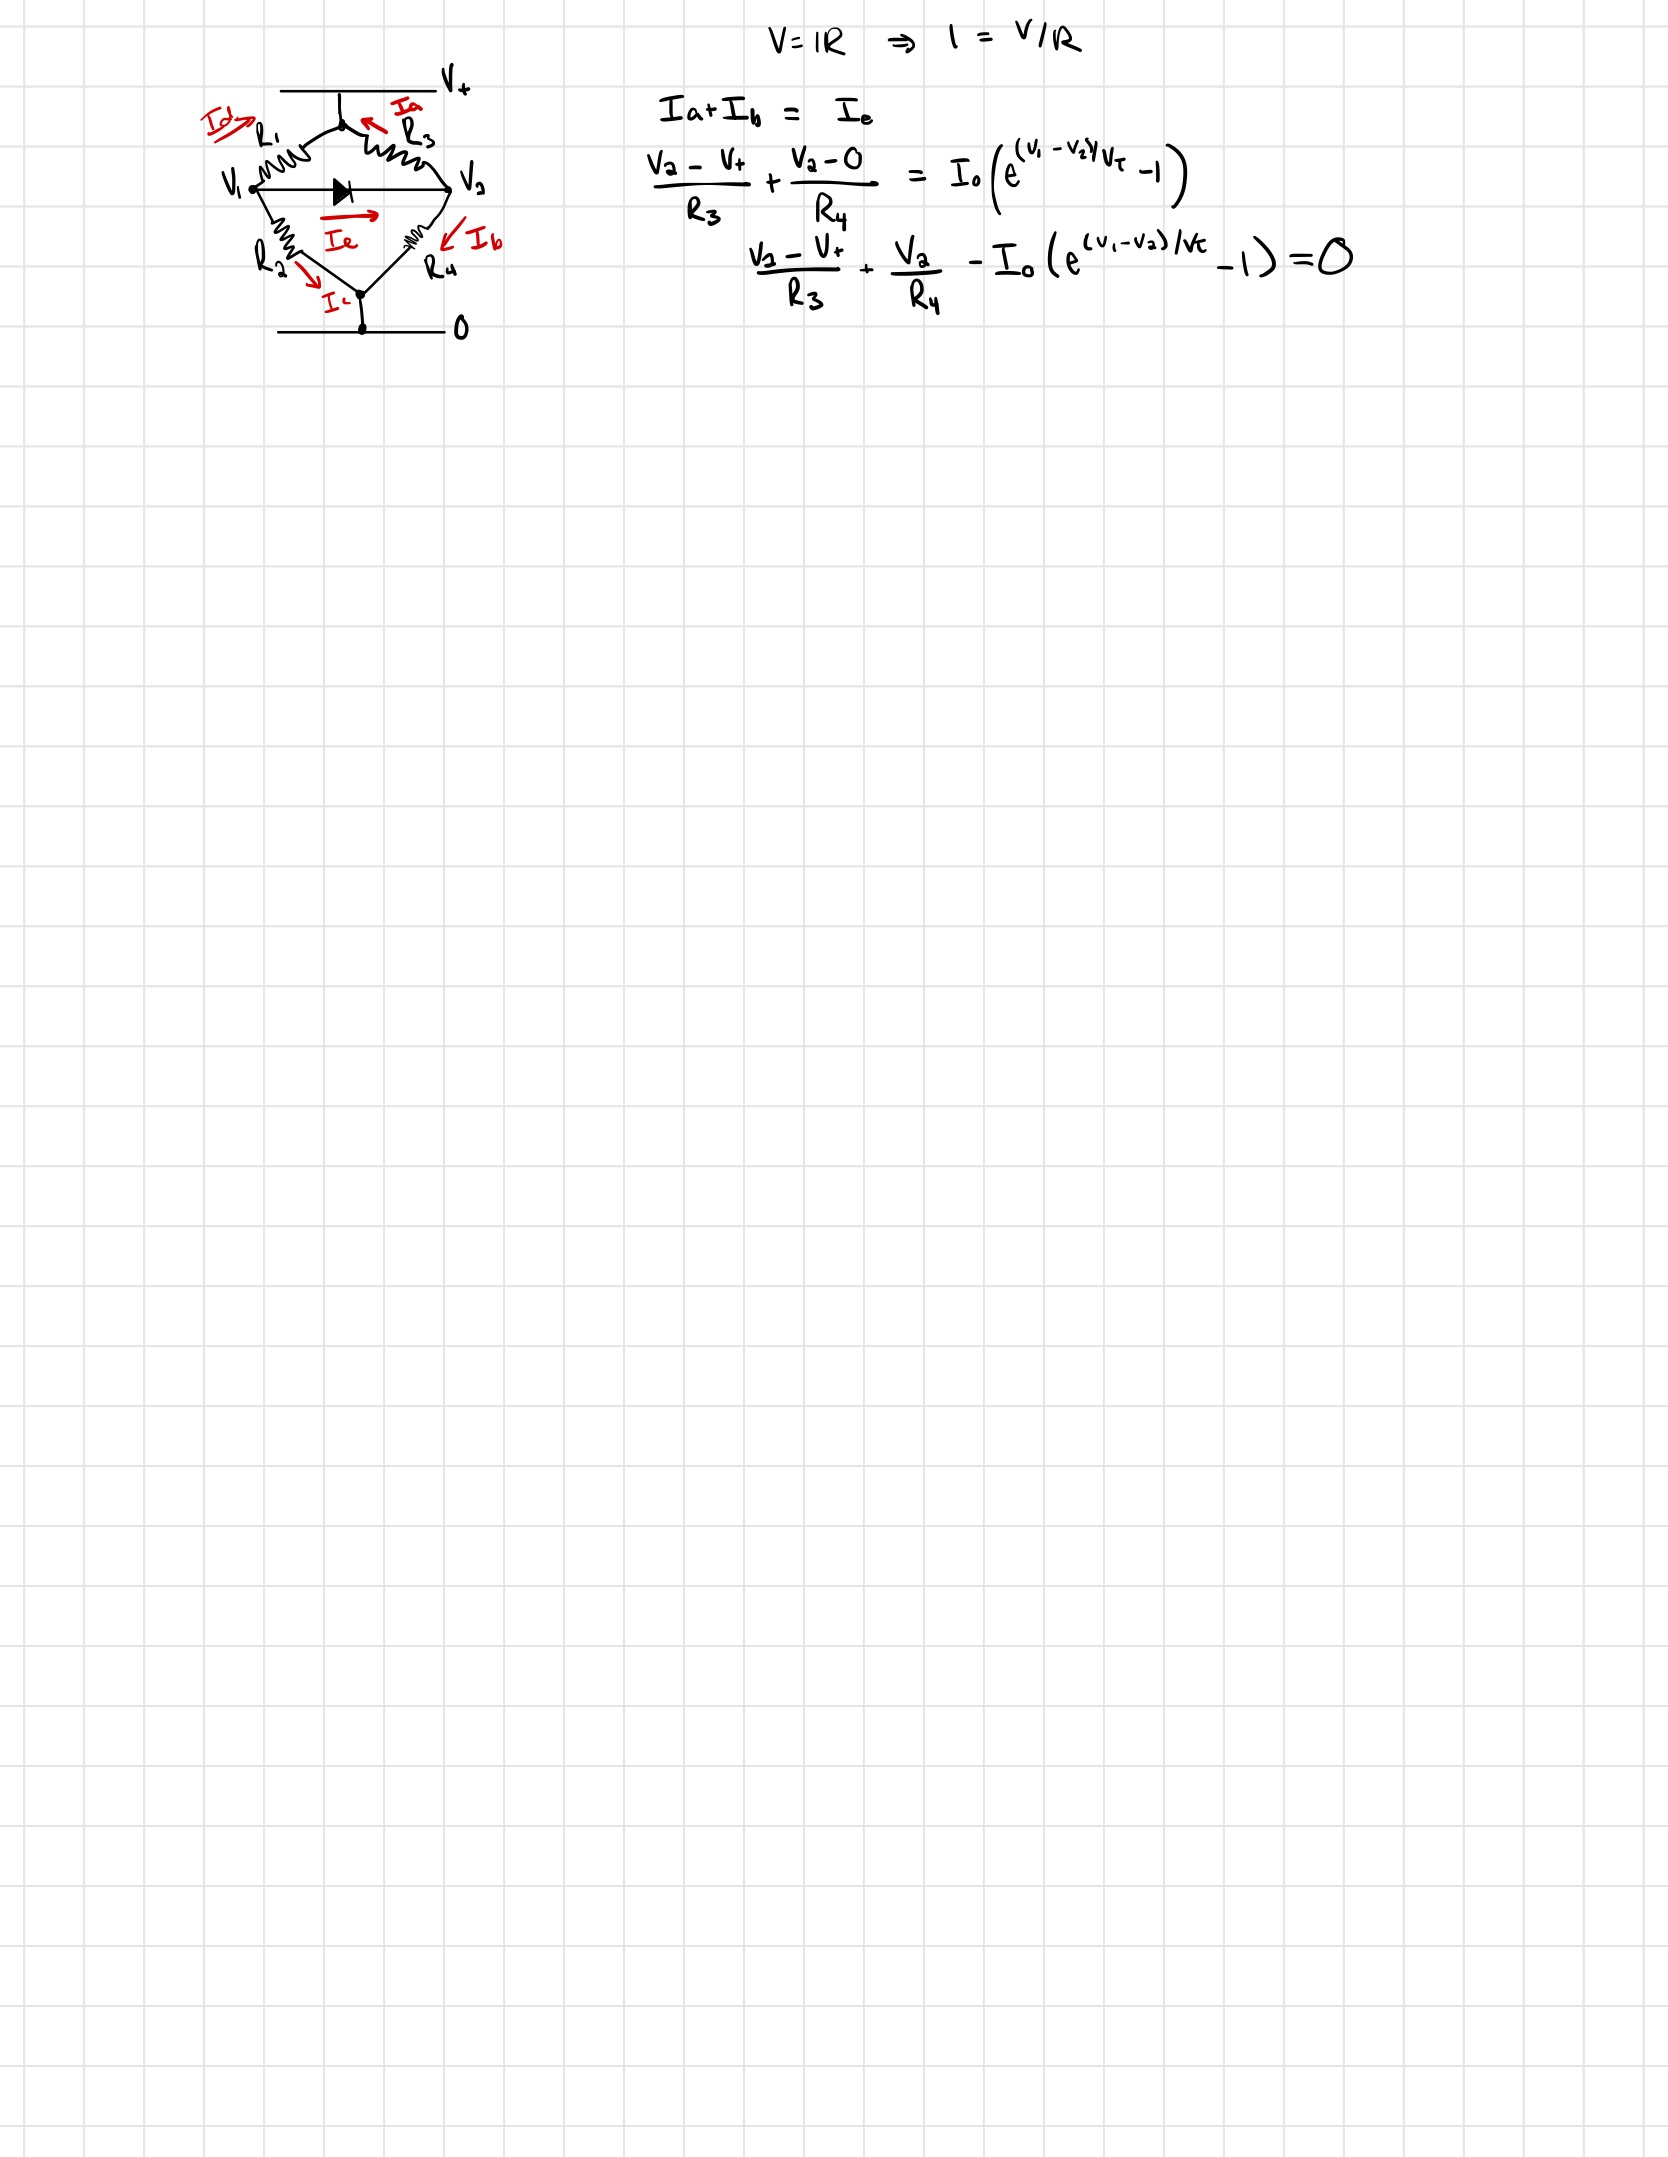

Question 4b

In [32]:
#initialize variables
v_plus = 5
r1 = 1e3
r2 = r3 = 4e3
r4 = 2e3
i0 = 3e-9
v_t = 0.05

#define the voltage equations from part a
def F(V):
    v1, v2 = V
    E = np.exp((v1-v2)/v_t)

    F1 = (v1 - v_plus)/r1 + v1/r2 + i0*(E-1)
    F2 = (v2 - v_plus)/r3 + v2/r4 - i0*(E-1)

    return np.array([F1, F2])

#define the Jacobian matrix
def J(V):
    v1, v2 = V
    E = np.exp((v1-v2)/v_t)
    a = i0/v_t * E

    return np.array([
        [1/r1 + 1/r2 + a, -a],
        [-a, 1/r3 + 1/r4 + a]
        ])

#another Newton's method for this problem
def newton2(v0, delta_v=1e-10, max_iter=1000):
    #guess intitial x vector
    v = np.array(v0, dtype=float)

    for _ in range(max_iter):
        #get delta x
        y = np.linalg.solve(J(v), -F(v))
        #update x vector
        v += y

        #check for convergence
        if np.linalg.norm(y) < delta_v:
            break

    return v
    
#get V1 and V2
sol = newton2([2.5, 2.5])

print("Voltage 1 is: ", sol[0])
print("Voltage 2 is: ", sol[1])
print("Diode Drop: ", sol[0] - sol[1]) # to verify based on 4c



Voltage 1 is:  3.359279080011553
Voltage 2 is:  2.7345348666474116
Diode Drop:  0.6247442133641412


Question 4c - skip